# PHYS 449 - Homework 1, Question 2

**Student Name:** Allen Mathew \
**Student ID:** 20964892 \
**Due Date:** Thursday, September 11, 3:00pm 
- - -


2. Consider the provided Python code for a 2D Ising model with N = 256
spins on a 16 × 16 periodic lattice:

100%|██████████| 30/30 [01:31<00:00,  3.03s/it]


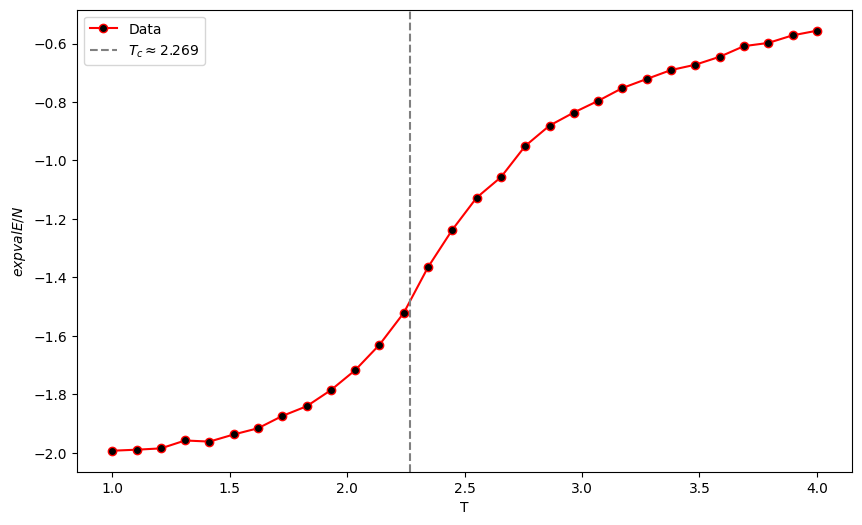

In [ ]:
"""
PHYS 449, F25, Homework 1, Problem 2
Monte Carlo program for the 2D Ising model

"""

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


def init_spins(L):
    return np.random.choice([-1, 1], size=(L, L))


def total_energy(spins, L, J):
    E = 0
    for i in range(L):
        for j in range(L):
            E += spins[i, j] * spins[i, (j + 1) % L]
            E += spins[i, j] * spins[(i + 1) % L, j]
    return -J * E


def energy_difference(spins, L, J, x, y):
    sigma_old = spins[x, y]

    sum_neighbors = (
        spins[(x + 1) % L, y]  # Bottom
        + spins[(x - 1) % L, y]  # Top
        + spins[x, (y + 1) % L]  # Right
        + spins[x, (y - 1) % L]  # Left
    )

    dE = 2 * J * sigma_old * sum_neighbors
    return dE


def metropolis_accept(deltaE, T):
    if deltaE < 0:
        return True
    else:
        acceptance_prob = np.exp(-deltaE / T)
        return acceptance_prob > np.random.rand()


def run_mcmc(L, n_samples, temperature, J=1.0):
    spins = init_spins(L)
    N = L * L

    current_energy = total_energy(spins, L, J)

    energies = []
    samples = []

    for sample in range(n_samples):
        for flip in range(N):
            x, y = np.random.randint(0, L, size=2)
            dE = energy_difference(spins, L, J, x, y)
            if metropolis_accept(dE, temperature):
                spins[x, y] *= -1
                current_energy += dE
        energies.append(current_energy)
        samples.append(spins.copy())

    return samples, energies


if __name__ == "__main__":
    L = 10
    N = L * L
    n_sweeps = 2000
    J = 1.0

    plt.style.use("default")

    temperatures = np.linspace(1.0, 4.0, 30)
    avg_energies = []

    for T in tqdm(temperatures):
        samples, energies = run_mcmc(L, n_sweeps, T, J)

        mean_energy_per_spin = np.mean(energies) / N
        avg_energies.append(mean_energy_per_spin)

    Tc = 2.269 * J

    plt.figure(figsize=(10, 6))
    plt.plot(
        temperatures,
        avg_energies,
        "o-",
        label="Data",
        color="red",
        markerfacecolor="black",
    )
    plt.axvline(x=Tc, color="gray", linestyle="--", label=f"$T_c \\approx {Tc:.3f}$")

    plt.xlabel("T")
    plt.ylabel(r"$expval{E}/N$")
    plt.legend()
    plt.show()


(a) Produce a dataset for *T* = 1.0, 2.7 and 4.0, consisting of vectors of length *N* for
each configuration of spins. The cardinality of each dataset should be $10^{4}$.

(b) Calculate the mean and standard deviation of the energy and magnetization for
each dataset.

(c) Are your dataset sample *i.i.d.*? Define and measure an autocorrelation time for
each dataset.

(d) Recalculate your mean and standard deviation, corrected to account for the autocorrelation time.